In [2]:
from google.colab import files

uploaded = files.upload()

Saving drug_consumption.data to drug_consumption.data


In [3]:
import pandas as pd

data = pd.read_csv("drug_consumption.data", header=None)

print(data.head())

   0        1        2        3        4        5        6        7        8   \
0   1  0.49788  0.48246 -0.05921  0.96082  0.12600  0.31287 -0.57545 -0.58331   
1   2 -0.07854 -0.48246  1.98437  0.96082 -0.31685 -0.67825  1.93886  1.43533   
2   3  0.49788 -0.48246 -0.05921  0.96082 -0.31685 -0.46725  0.80523 -0.84732   
3   4 -0.95197  0.48246  1.16365  0.96082 -0.31685 -0.14882 -0.80615 -0.01928   
4   5  0.49788  0.48246  1.98437  0.96082 -0.31685  0.73545 -1.63340 -0.45174   

        9   ...   22   23   24   25   26   27   28   29   30   31  
0 -0.91699  ...  CL0  CL0  CL0  CL0  CL0  CL0  CL0  CL2  CL0  CL0  
1  0.76096  ...  CL4  CL0  CL2  CL0  CL2  CL3  CL0  CL4  CL0  CL0  
2 -1.62090  ...  CL0  CL0  CL0  CL0  CL0  CL0  CL1  CL0  CL0  CL0  
3  0.59042  ...  CL0  CL0  CL2  CL0  CL0  CL0  CL0  CL2  CL0  CL0  
4 -0.30172  ...  CL1  CL0  CL0  CL1  CL0  CL0  CL2  CL2  CL0  CL0  

[5 rows x 32 columns]


In [4]:
print(data.columns)

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype='int64')


In [5]:
X = data.iloc[:, 1:13]
y = data.iloc[:, 18]

print("Input data:")
print(X.head())

print("\nTarget data:")
print(y.head())

Input data:
        1        2        3        4        5        6        7        8   \
0  0.49788  0.48246 -0.05921  0.96082  0.12600  0.31287 -0.57545 -0.58331   
1 -0.07854 -0.48246  1.98437  0.96082 -0.31685 -0.67825  1.93886  1.43533   
2  0.49788 -0.48246 -0.05921  0.96082 -0.31685 -0.46725  0.80523 -0.84732   
3 -0.95197  0.48246  1.16365  0.96082 -0.31685 -0.14882 -0.80615 -0.01928   
4  0.49788  0.48246  1.98437  0.96082 -0.31685  0.73545 -1.63340 -0.45174   

        9        10       11       12  
0 -0.91699 -0.00665 -0.21712 -1.18084  
1  0.76096 -0.14277 -0.71126 -0.21575  
2 -1.62090 -1.01450 -1.37983  0.40148  
3  0.59042  0.58489 -1.37983 -1.18084  
4 -0.30172  1.30612 -0.21712 -0.21575  

Target data:
0    CL0
1    CL4
2    CL3
3    CL2
4    CL3
Name: 18, dtype: object


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 1508
Testing data: 377


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
['CL0' 'CL1' 'CL6' 'CL0' 'CL4' 'CL6' 'CL4' 'CL4' 'CL6' 'CL2']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy,4))

Accuracy: 0.2918


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         CL0       0.50      0.42      0.46        86
         CL1       0.20      0.32      0.25        28
         CL2       0.22      0.20      0.21        55
         CL3       0.06      0.04      0.04        57
         CL4       0.06      0.07      0.07        27
         CL5       0.17      0.25      0.21        32
         CL6       0.42      0.46      0.44        92

    accuracy                           0.29       377
   macro avg       0.23      0.25      0.24       377
weighted avg       0.29      0.29      0.29       377



In [9]:
import pandas as pd
import matplotlib.pyplot as plt

cols = ["ID", "Age", "Gender", "Education", "Country", "Ethnicity",
        "Nscore", "Escore", "Oscore", "Ascore", "Cscore", "Impulsive", "SS",
        "Alcohol", "Amphet", "Amyl", "Benzos", "Caffeine", "Cannabis", "Choc",
        "Coke", "Crack", "Ecstasy", "Heroin", "Ketamine", "Legalh", "LSD",
        "Meth", "Mushrooms", "Nicotine", "Semer", "VSA"]
df = pd.read_csv("drug_consumption.data", header=None, names=cols)

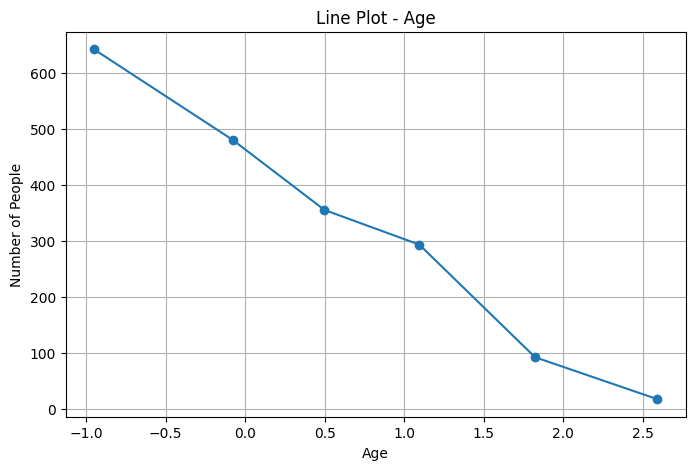

In [10]:
# Line Plot - Age

age_count = df["Age"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(age_count.index, age_count.values, marker='o')

plt.title("Line Plot - Age")
plt.xlabel("Age")
plt.ylabel("Number of People")
plt.grid(True)

plt.show()

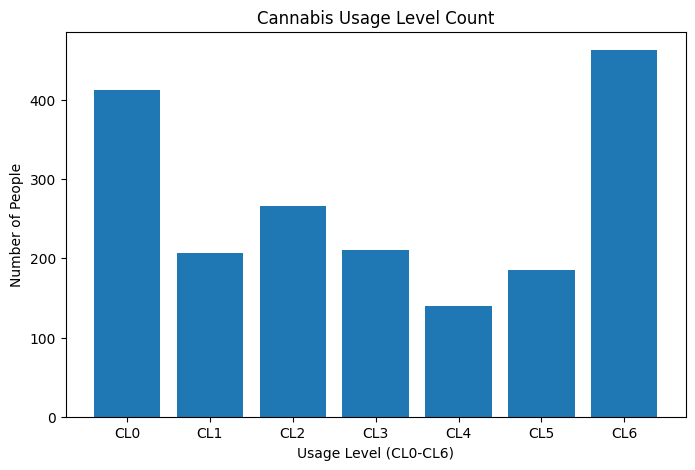

In [11]:
# Bar Chart - Cannabis Usage Level

cannabis_count = df["Cannabis"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cannabis_count.index, cannabis_count.values)

plt.title("Cannabis Usage Level Count")
plt.xlabel("Usage Level (CL0-CL6)")
plt.ylabel("Number of People")

plt.show()

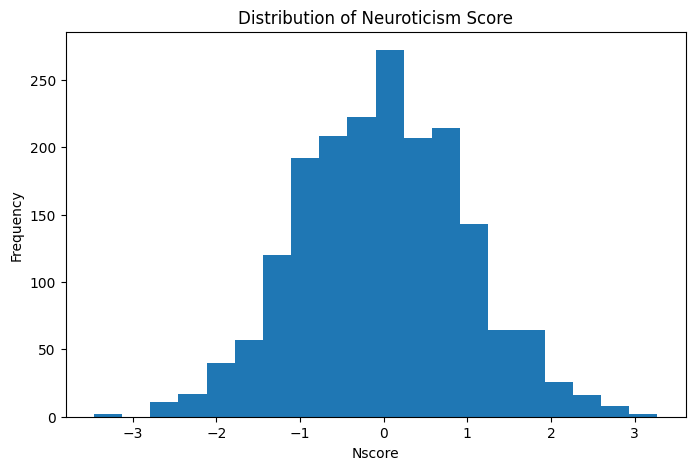

In [12]:
# Histogram - Neuroticism Score

plt.figure(figsize=(8, 5))

plt.hist(df["Nscore"].dropna(), bins=20)

plt.title("Distribution of Neuroticism Score")
plt.xlabel("Nscore")
plt.ylabel("Frequency")

plt.show()

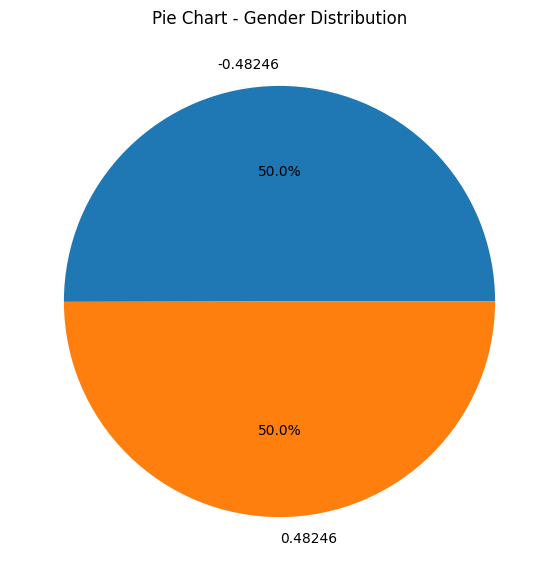

In [13]:
# Pie Chart - Gender

gender_count = df["Gender"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    gender_count.values,
    labels=gender_count.index.astype(str),
    autopct='%1.1f%%'
)

plt.title("Pie Chart - Gender Distribution")

plt.show()

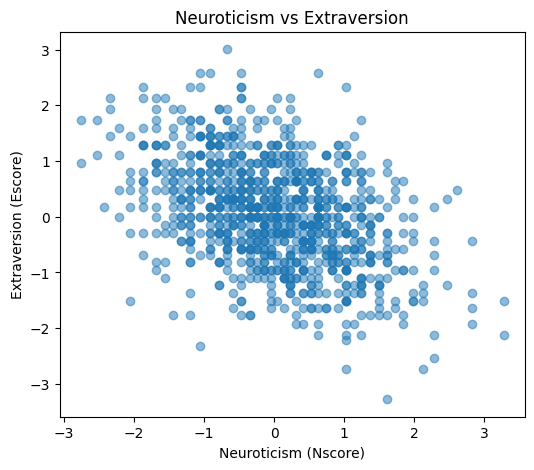

In [14]:
sample = df[["Nscore", "Escore"]].dropna().head(1000)

plt.figure(figsize=(6, 5))
plt.scatter(sample["Nscore"], sample["Escore"], alpha=0.5)
plt.title("Neuroticism vs Extraversion")
plt.xlabel("Neuroticism (Nscore)")
plt.ylabel("Extraversion (Escore)")
plt.show()

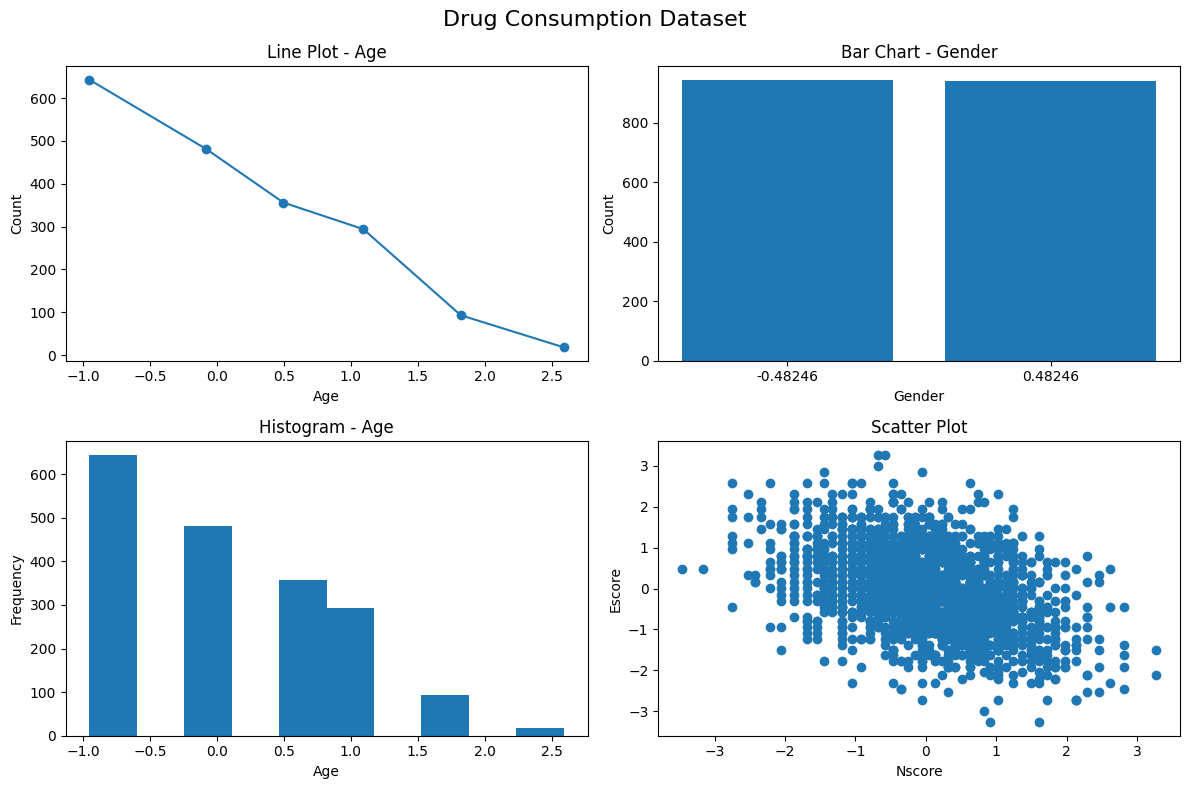

In [ ]:
# Subplots

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(age_count.index, age_count.values, marker='o')
plt.title("Line Plot - Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.subplot(2, 2, 2)
plt.bar(gender_count.index.astype(str), gender_count.values)
plt.title("Bar Chart - Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.subplot(2, 2, 3)
plt.hist(df["Age"], bins=10)
plt.title("Histogram - Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.subplot(2, 2, 4)
plt.scatter(df["Nscore"], df["Escore"])
plt.title("Scatter Plot")
plt.xlabel("Nscore")
plt.ylabel("Escore")

plt.suptitle("Drug Consumption Dataset", fontsize=16)

plt.tight_layout()
plt.show()